In [189]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.naive_bayes import MultinomialNB,GaussianNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
print("Customer Churn Project -> ")


Customer Churn Project -> 


In [190]:
print("Data Uploading is done!")
df=pd.read_csv("customer_churn.csv")
data=pd.DataFrame(df)
print("Data Dimension :",data.shape)


Data Uploading is done!
Data Dimension : (7043, 21)


In [191]:
print("Data Features : ")
print(data.info())

Data Features : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 no

In [192]:
print("Converting the TotalCharges from categorical to numerical")
data["TotalCharges"]=pd.to_numeric(data["TotalCharges"],errors="coerce")
print(data.info())

Converting the TotalCharges from categorical to numerical
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null

In [193]:
print("Check Null Values:\n",data.isnull().sum())


Check Null Values:
 customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [194]:
print("Let's Clean the data by dropping the TotalCharges 11 null rows")
data=data.dropna(subset=["TotalCharges"])
print(data.isnull().sum())

Let's Clean the data by dropping the TotalCharges 11 null rows
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [195]:
print("Now the data is cleaned ")
print("Now the data and target varible splitting :")
X=data.drop("Churn",axis=1)
X=X.drop("customerID",axis=1)
y=data["Churn"]
categorical_columns=X.select_dtypes(include="object").columns
numerical_columns=X.select_dtypes(exclude="object").columns
print("Categorical Columns : ")
print(categorical_columns)
print()
print("Numerical Columns : ")
print(numerical_columns)

Now the data is cleaned 
Now the data and target varible splitting :
Categorical Columns : 
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Numerical Columns : 
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [196]:

scaler=StandardScaler()
encoder=OneHotEncoder(handle_unknown="ignore",drop="first")
print("Training and Testing Set Splitting is done ! ")
X_train,X_test,y_train,y_test=train_test_split(X,
                                               y,
                                               test_size=0.4,
                                               random_state=10)
      
X_train_encoded=encoder.fit_transform(X_train[categorical_columns])
X_test_encoded=encoder.transform(X_test[categorical_columns])
print("Encoding is Done !")
X_train_scaled=scaler.fit_transform(X_train[numerical_columns])
X_test_scaled=scaler.transform(X_test[numerical_columns])
print("Standardizing the numerical features is done !")




Training and Testing Set Splitting is done ! 
Encoding is Done !
Standardizing the numerical features is done !


In [197]:
print("Encoded categorical:", X_train_encoded.shape)
print("Scaled numerical:", X_train_scaled.shape)

print("Test encoded categorical:", X_test_encoded.shape)
print("Test scaled numerical:", X_test_scaled.shape)

Encoded categorical: (4219, 26)
Scaled numerical: (4219, 4)
Test encoded categorical: (2813, 26)
Test scaled numerical: (2813, 4)


In [198]:
print("Combining the datasets : ")
X_train_final=np.hstack([X_train_encoded.toarray(),X_train_scaled])
X_test_final=np.hstack([X_test_encoded.toarray(),X_test_scaled])
'''from scipy.sparse import hstack
    X_train_final = hstack([
    X_train_encoded,
    X_train_scaled
])'''


print(X_train_final)

Combining the datasets : 
[[ 1.          1.          0.         ... -0.73353843 -1.53846949
  -0.89322162]
 [ 0.          0.          0.         ... -1.01750213 -1.19275341
  -0.92286831]
 [ 1.          1.          1.         ... -0.04391231  0.94770879
   0.22572275]
 ...
 [ 0.          1.          0.         ...  0.7268463  -0.5178627
   0.09139711]
 [ 1.          0.          0.         ... -1.13920086  0.89973862
  -0.82444567]
 [ 1.          1.          1.         ...  1.37590618  1.51838844
   2.26146907]]


In [213]:
model1=LogisticRegression()
model2=KNeighborsClassifier(n_neighbors=5)
param_grid={"n_neighbors":[1,3,5,9,11]}
grid_search=GridSearchCV(KNeighborsClassifier(),param_grid,cv=5)
model3=SVC(kernel="linear",C=1000,gamma="scale")
model4=SVC(kernel="poly",C=1000,gamma="scale")
model5=SVC(kernel="rbf",C=1000,gamma="scale")
model6=MultinomialNB()
model7=GaussianNB()
model8=DecisionTreeClassifier(max_depth=2,random_state=42)



Model 1 : Logistic Regression 
['No' 'No' 'No' ... 'No' 'No' 'No']
Classification Report : 
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      2075
         Yes       0.65      0.57      0.61       738

    accuracy                           0.81      2813
   macro avg       0.75      0.73      0.74      2813
weighted avg       0.80      0.81      0.80      2813

Confusion matrix : 
 [[1852  223]
 [ 316  422]]


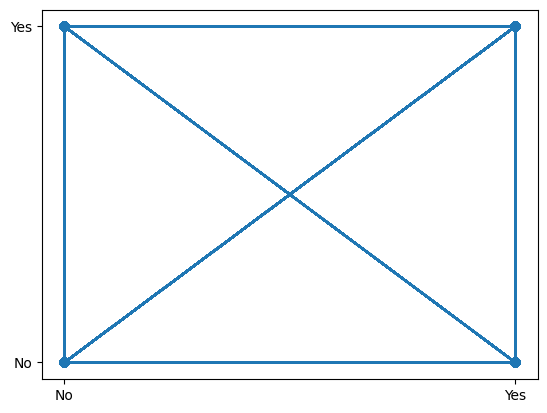

In [233]:
from sklearn.metrics import classification_report,confusion_matrix
import matplotlib.pyplot as plt
print("Model 1 : Logistic Regression ")
model1.fit(X_train_final,y_train)
y1=model1.predict(X_test_final)
print(y1)
print("Classification Report : ")
print(classification_report(y_test,y1))
cm1=confusion_matrix(y_test,y1)
print("Confusion matrix : \n",cm1)
print(plt.plot(y_test,y1,label="Logistic Regression",marker="o"))

In [249]:
models = [
    model1,  # 1 Logistic Regression
    model2,  # 2 KNN
    model3,  # 3 SVC Linear
    model4,  # 4 SVC Polynomial
    model5,  # 5 SVC RBF
    model6,  # 6 Multinomial NB
    model7,  # 7 Gaussian NB
    model8   # 8 Decision Tree
]

choice = int(input("""
================================
     CLASSIFICATION MODELS
================================

1. Logistic Regression
2. KNN
3. SVC - Linear
4. SVC - Polynomial
5. SVC - RBF
6. Multinomial Naive Bayes
7. Gaussian Naive Bayes
8. Decision Tree

Enter your choice: 
"""))

model = None

for i in range(len(models)):
    
    if choice == i + 1:
        model = models[i]
        break

if model is None:
    print("Invalid choice")

else:
    print("\nSelected Model:", model)

    model.fit(X_train_final, y_train)

    y_pred = model.predict(X_test_final)

    print("\nPrediction:")
    print(y_pred)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)


     CLASSIFICATION MODELS

1. Logistic Regression
2. KNN
3. SVC - Linear
4. SVC - Polynomial
5. SVC - RBF
6. Multinomial Naive Bayes
7. Gaussian Naive Bayes
8. Decision Tree

Enter your choice: 
 2



Selected Model: KNeighborsClassifier()

Prediction:
['No' 'No' 'No' ... 'No' 'No' 'No']

Classification Report:
              precision    recall  f1-score   support

          No       0.83      0.84      0.84      2075
         Yes       0.54      0.53      0.53       738

    accuracy                           0.76      2813
   macro avg       0.69      0.68      0.68      2813
weighted avg       0.76      0.76      0.76      2813


Confusion Matrix:
[[1736  339]
 [ 346  392]]


In [259]:
choice = int(input("""CLASSIFICATION GAME:

1. Logistic Regression
2. KNN
3. SVC - LINEAR
4. SVC - POLYNOMIAL
5. SVC - RBF
6. MULTINOMIAL NAIVE BAYES
7. GAUSSIAN NAIVE BAYES
8. DECISION TREE

ENTER YOUR CHOICE:
"""))

model = None

match choice:

    case 1:
        model = model1

    case 2:
        model = model2

    case 3:
        model = model3

    case 4:
        model = model4

    case 5:
        model = model5

    case 6:
        model = model6

    case 7:
        model = model7

    case 8:
        model = model8

    case _:
        print("Invalid choice")


if model is not None:

    print("\nSelected Model:", model)
    
    print("\nTraining the model...")
    model.fit(X_train_final, y_train)

    print("Training completed!")

    y_pred = model.predict(X_test_final)

    print("Prediction completed!")

    print("\nPredictions:")
    print(y_pred)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

CLASSIFICATION GAME:

1. Logistic Regression
2. KNN
3. SVC - LINEAR
4. SVC - POLYNOMIAL
5. SVC - RBF
6. MULTINOMIAL NAIVE BAYES
7. GAUSSIAN NAIVE BAYES
8. DECISION TREE

ENTER YOUR CHOICE:
 5



Selected Model: SVC(C=1000)

Training the model...
Training completed!
Prediction completed!

Predictions:
['No' 'No' 'No' ... 'No' 'No' 'No']

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.81      0.81      2075
         Yes       0.48      0.51      0.49       738

    accuracy                           0.73      2813
   macro avg       0.65      0.66      0.65      2813
weighted avg       0.73      0.73      0.73      2813


Confusion Matrix:
[[1672  403]
 [ 363  375]]



       CLASSIFICATION GAME

Choose your model:

1. Logistic Regression
2. KNN
3. SVC - Linear
4. SVC - Polynomial
5. SVC - RBF
6. Multinomial Naive Bayes
7. Gaussian Naive Bayes
8. Decision Tree

Enter your choice: 
 5



MODEL: SVC - RBF

🔄 Training model...
✅ Training completed!
✅ Prediction completed!

CLASSIFICATION REPORT
              precision    recall  f1-score   support

          No       0.82      0.81      0.81      2075
         Yes       0.48      0.51      0.49       738

    accuracy                           0.73      2813
   macro avg       0.65      0.66      0.65      2813
weighted avg       0.73      0.73      0.73      2813


MODEL PERFORMANCE
Accuracy  : 0.727692854603626
Precision : 0.4820051413881748
Recall    : 0.508130081300813
F1 Score  : 0.4947229551451187

CONFUSION MATRIX
[[1672  403]
 [ 363  375]]


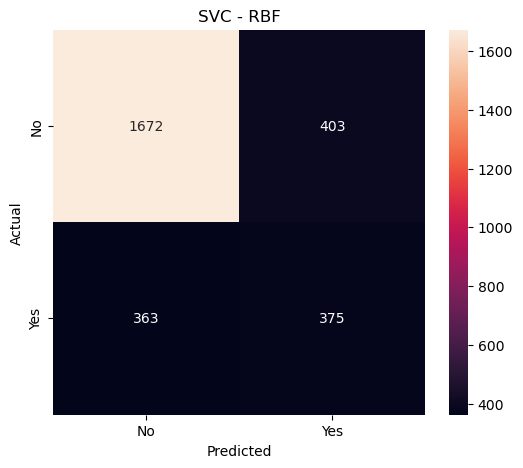

In [257]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns


choice = int(input("""
========================================
       CLASSIFICATION GAME
========================================

Choose your model:

1. Logistic Regression
2. KNN
3. SVC - Linear
4. SVC - Polynomial
5. SVC - RBF
6. Multinomial Naive Bayes
7. Gaussian Naive Bayes
8. Decision Tree

Enter your choice: 
"""))


# -----------------------------------
# MODEL SELECTION
# -----------------------------------

match choice:

    case 1:
        model = model1
        model_name = "Logistic Regression"

    case 2:
        model = grid_search
        model_name = "KNN + GridSearch"

    case 3:
        model = model3
        model_name = "SVC - Linear"

    case 4:
        model = model4
        model_name = "SVC - Polynomial"

    case 5:
        model = model5
        model_name = "SVC - RBF"

    case 6:
        model = model6
        model_name = "Multinomial Naive Bayes"

    case 7:
        model = model7
        model_name = "Gaussian Naive Bayes"

    case 8:
        model = model8
        model_name = "Decision Tree"

    case _:
        print("❌ Invalid choice!")
        model = None


# -----------------------------------
# TRAINING + PREDICTION
# -----------------------------------

if model is not None:

    print("\n========================================")
    print("MODEL:", model_name)
    print("========================================")

    print("\n🔄 Training model...")

    model.fit(X_train_final, y_train)

    print("✅ Training completed!")

    # Prediction
    y_pred = model.predict(X_test_final)

    print("✅ Prediction completed!")


    # -----------------------------------
    # GRID SEARCH INFORMATION
    # -----------------------------------

    if choice == 2:

        print("\nBest KNN Parameters:")
        print(model.best_params_)

        print("\nBest Cross Validation Score:")
        print(model.best_score_)


    # -----------------------------------
    # CLASSIFICATION REPORT
    # -----------------------------------

    print("\n========================================")
    print("CLASSIFICATION REPORT")
    print("========================================")

    print(classification_report(y_test, y_pred))


    # -----------------------------------
    # INDIVIDUAL METRICS
    # -----------------------------------

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        pos_label="Yes"
    )

    recall = recall_score(
        y_test,
        y_pred,
        pos_label="Yes"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label="Yes"
    )

    print("\n========================================")
    print("MODEL PERFORMANCE")
    print("========================================")

    print("Accuracy  :", accuracy)
    print("Precision :", precision)
    print("Recall    :", recall)
    print("F1 Score  :", f1)


    # -----------------------------------
    # CONFUSION MATRIX
    # -----------------------------------

    cm = confusion_matrix(y_test, y_pred)

    print("\n========================================")
    print("CONFUSION MATRIX")
    print("========================================")

    print(cm)


    # -----------------------------------
    # CONFUSION MATRIX HEATMAP
    # -----------------------------------

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(model_name)

    plt.show()